# 3D Object Generation from Image

Uses the trained `Furniture3D` (Pixel2Mesh-style) model to deform a unit cube into a 3D mesh from a single input image.

**Checkpoint:** `furniture3d_smoke.pth` — trained with `hidden_dim=64, n_stages=3, n_gcn_blocks=1`

In [1]:
import torch
import numpy as np
import torch.nn.functional as F
from torch import nn
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

DEVICE = torch.device("cpu")
CKPT_PATH = "./furniture3d_smoke.pth"
print("Device:", DEVICE)

Device: cpu


## Model Architecture (copy from notebook 5)

In [2]:
def get_unit_cube():
    v = torch.tensor([
        [-0.5,-0.5,-0.5],[0.5,-0.5,-0.5],[0.5,0.5,-0.5],[-0.5,0.5,-0.5],
        [-0.5,-0.5,0.5],[0.5,-0.5,0.5],[0.5,0.5,0.5],[-0.5,0.5,0.5],
    ], dtype=torch.float32)
    f = torch.tensor([
        [0,1,2],[0,2,3],[4,6,5],[4,7,6],[0,4,5],[0,5,1],
        [2,6,7],[2,7,3],[0,7,4],[0,3,7],[1,5,6],[1,6,2],
    ], dtype=torch.long)
    return v, f


def loop_subdivide(vertices, faces):
    V = vertices.shape[0]
    edges_dict, mids = {}, []

    def midpoint(a, b):
        key = (min(a,b), max(a,b))
        if key not in edges_dict:
            edges_dict[key] = len(mids) + V
            mids.append((vertices[a] + vertices[b]) / 2.0)
        return edges_dict[key]

    new_faces = []
    for tri in faces.numpy():
        v0,v1,v2 = int(tri[0]),int(tri[1]),int(tri[2])
        m01,m12,m20 = midpoint(v0,v1),midpoint(v1,v2),midpoint(v2,v0)
        new_faces += [[v0,m01,m20],[v1,m12,m01],[v2,m20,m12],[m01,m12,m20]]

    new_v = torch.cat([vertices, torch.stack(mids)], 0) if mids else vertices
    new_f = torch.tensor(new_faces, dtype=torch.long)
    return new_v, new_f


def build_adjacency(vertices, faces):
    V = vertices.shape[0]
    adj = torch.zeros(V, V)
    for tri in faces:
        for i in range(3):
            a,b = int(tri[i]),int(tri[(i+1)%3])
            adj[a,b] = adj[b,a] = 1.0
    adj += torch.eye(V)
    return adj / adj.sum(1, keepdim=True).clamp(min=1)


def build_laplacian(vertices, faces):
    V = vertices.shape[0]
    adj = torch.zeros(V, V)
    for tri in faces:
        for i in range(3):
            a,b = int(tri[i]),int(tri[(i+1)%3])
            adj[a,b] = adj[b,a] = 1.0
    return torch.eye(V) - adj / adj.sum(1, keepdim=True).clamp(1)

In [3]:
def project_vertices(vertices, rot, trans, focal):
    v_cam = torch.bmm(vertices, rot.transpose(1,2)) + trans.unsqueeze(1)
    z = v_cam[...,2:3].clamp(min=1e-6)
    f = focal.view(-1,1,1)
    xy = f * v_cam[...,:2] / z
    return xy.clamp(-1,1)


def sample_features(feature_maps, coords):
    grid = coords.unsqueeze(1)
    sampled = []
    for fm in feature_maps:
        s = F.grid_sample(fm, grid, align_corners=True, mode="bilinear", padding_mode="border")
        sampled.append(s.squeeze(2).permute(0,2,1))
    return torch.cat(sampled, dim=-1)


class ResNetEncoder(nn.Module):
    def __init__(self, pretrained=True, freeze_stages=2):
        super().__init__()
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        bb = resnet50(weights=weights)
        self.stem   = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3
        self.layer4 = bb.layer4
        self.feat_dims = [256,512,1024,2048]
        for stage in [self.stem, self.layer1, self.layer2][:freeze_stages]:
            for p in stage.parameters(): p.requires_grad = False

    def forward(self, x):
        x = self.stem(x)
        return [self.layer1(x), self.layer2(self.layer1(x)),
                self.layer3(self.layer2(self.layer1(x))),
                self.layer4(self.layer3(self.layer2(self.layer1(x))))]


class ResNetEncoder(nn.Module):
    def __init__(self, pretrained=True, freeze_stages=2):
        super().__init__()
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        bb = resnet50(weights=weights)
        self.stem   = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3
        self.layer4 = bb.layer4
        self.feat_dims = [256,512,1024,2048]
        for stage in [self.stem, self.layer1, self.layer2][:freeze_stages]:
            for p in stage.parameters(): p.requires_grad = False

    def forward(self, x):
        x  = self.stem(x)
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return [f1, f2, f3, f4]


class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc_self  = nn.Linear(in_dim, out_dim, bias=False)
        self.fc_neigh = nn.Linear(in_dim, out_dim, bias=False)
        self.bn   = nn.BatchNorm1d(out_dim)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj):
        B, V, _ = x.shape
        neigh = torch.einsum("vw,bwf->bvf", adj, x)
        out   = self.fc_self(x) + self.fc_neigh(neigh) + self.bias
        out   = self.bn(out.reshape(B*V,-1)).reshape(B,V,-1)
        return F.relu(out)


class GCNBlock(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.gc1  = GraphConv(in_dim, hidden_dim)
        self.gc2  = GraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(in_dim, hidden_dim, bias=False) if in_dim != hidden_dim else nn.Identity()

    def forward(self, x, adj):
        return self.gc2(self.gc1(x, adj), adj) + self.skip(x)


class DeformStage(nn.Module):
    def __init__(self, feat_dim, hidden_dim=128, n_blocks=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            GCNBlock(feat_dim if i==0 else hidden_dim, hidden_dim)
            for i in range(n_blocks)
        ])
        self.disp_head = nn.Sequential(
            nn.Linear(hidden_dim,64), nn.ReLU(), nn.Linear(64,3)
        )

    def forward(self, feats, verts, adj):
        h = feats
        for blk in self.blocks: h = blk(h, adj)
        return verts + self.disp_head(h), h


class Furniture3D(nn.Module):
    def __init__(self, encoder, hidden_dim=128, n_stages=3, n_gcn_blocks=2):
        super().__init__()
        self.n_stages   = n_stages
        self.hidden_dim = hidden_dim
        self.encoder    = encoder
        total_img = sum(self.encoder.feat_dims)

        self.projectors    = nn.ModuleList()
        self.deform_stages = nn.ModuleList()
        for i in range(n_stages):
            in_dim = (total_img + 3) if i == 0 else (total_img + hidden_dim + 3)
            self.projectors.append(nn.Sequential(
                nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            ))
            self.deform_stages.append(DeformStage(hidden_dim, hidden_dim, n_gcn_blocks))

        self._build_templates(n_stages)

    def _build_templates(self, n_stages):
        verts, faces = get_unit_cube()
        self.templates = []
        for i in range(n_stages):
            adj = build_adjacency(verts, faces)
            lap = build_laplacian(verts, faces)
            self.register_buffer(f"adj_{i}", adj)
            self.register_buffer(f"lap_{i}", lap)
            self.templates.append((verts.clone(), faces.clone()))
            if i < n_stages - 1:
                verts, faces = loop_subdivide(verts, faces)

    def forward(self, image, rot, trans, focal):
        B, device = image.shape[0], image.device
        feat_maps = self.encoder(image)
        all_verts, all_faces, all_laps = [], [], []
        prev_h = None

        for i in range(self.n_stages):
            adj = getattr(self, f"adj_{i}").to(device)
            lap = getattr(self, f"lap_{i}").to(device)
            verts_tmpl, faces = self.templates[i]
            verts = verts_tmpl.to(device).unsqueeze(0).expand(B,-1,-1).clone()
            V = verts.shape[1]

            coords   = project_vertices(verts, rot, trans, focal)
            img_feat = sample_features(feat_maps, coords)

            if prev_h is None:
                combined = torch.cat([img_feat, verts], dim=-1)
            else:
                if prev_h.shape[1] != V:
                    prev_h = F.interpolate(
                        prev_h.permute(0,2,1), size=V, mode="linear", align_corners=False
                    ).permute(0,2,1)
                combined = torch.cat([img_feat, prev_h, verts], dim=-1)

            vertex_feats = self.projectors[i](combined)
            new_verts, hidden = self.deform_stages[i](vertex_feats, verts, adj)

            all_verts.append(new_verts)
            all_faces.append(faces)
            all_laps.append(lap)
            prev_h = hidden

        return {"vertices": all_verts, "faces": all_faces, "laplacians": all_laps}

## Load checkpoint

The smoke checkpoint was saved from a model with `hidden_dim=64, n_stages=3, n_gcn_blocks=1`.

In [4]:
encoder = ResNetEncoder(pretrained=True, freeze_stages=2).to(DEVICE)

model = Furniture3D(
    encoder=encoder,
    hidden_dim=64,      # must match what was used during training
    n_stages=3,
    n_gcn_blocks=1,
).to(DEVICE)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded checkpoint — epoch {ckpt['epoch']}, val_cd={ckpt.get('val_cd')}")

Loaded checkpoint — epoch 0, val_cd=None


## Run inference

### Camera parameters

The model needs three camera parameters alongside the image:

| Parameter | Shape | Meaning |
|-----------|-------|---------|
| `rot`   | `[1,3,3]` | Rotation matrix (world → camera). Use `torch.eye(3)` if unknown. |
| `trans` | `[1,3]`   | Translation (world → camera). `[0, 0, 2]` puts the object 2 units in front. |
| `focal` | `[1]`     | Normalised focal length = `focal_px / (max(W,H)/2)`. Use `0.85` as a safe default. |

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def load_image(path_or_pil):
    """Load an image from a file path or PIL Image and return a [1,3,224,224] tensor."""
    if isinstance(path_or_pil, str):
        img = Image.open(path_or_pil).convert("RGB")
    else:
        img = path_or_pil.convert("RGB")
    return preprocess(img).unsqueeze(0)  # [1,3,224,224]


def make_camera(rot=None, trans_z=2.0, focal=0.85):
    """Build default camera tensors."""
    r = rot if rot is not None else torch.eye(3)
    r = r.unsqueeze(0)                              # [1,3,3]
    t = torch.tensor([[0., 0., trans_z]])           # [1,3]
    f = torch.tensor([focal])                       # [1]
    return r, t, f

In [6]:
# ── Option A: load from file ──────────────────────────────────────────────
# img_tensor = load_image("path/to/your/image.jpg")

# ── Option B: use a synthetic image (demo) ────────────────────────────────
synthetic = torch.zeros(3, 224, 224)
synthetic[:, 50:180, 60:160] = 0.8    # body
synthetic[:, 160:200, 70:90] = 0.6    # left leg
synthetic[:, 160:200, 130:150] = 0.6  # right leg
synthetic[:, 50:80, 60:160]  = 0.9    # backrest
img_tensor = synthetic.unsqueeze(0)   # [1,3,224,224]

rot, trans, focal = make_camera(trans_z=2.0, focal=0.85)

with torch.no_grad():
    output = model(
        img_tensor.to(DEVICE),
        rot.to(DEVICE),
        trans.to(DEVICE),
        focal.to(DEVICE),
    )

for i, v in enumerate(output["vertices"]):
    f = output["faces"][i]
    print(f"Stage {i+1}: {v.shape[1]} vertices, {f.shape[0]} faces")

Stage 1: 8 vertices, 12 faces
Stage 2: 26 vertices, 48 faces
Stage 3: 98 vertices, 192 faces


## Visualise the 3 deformation stages

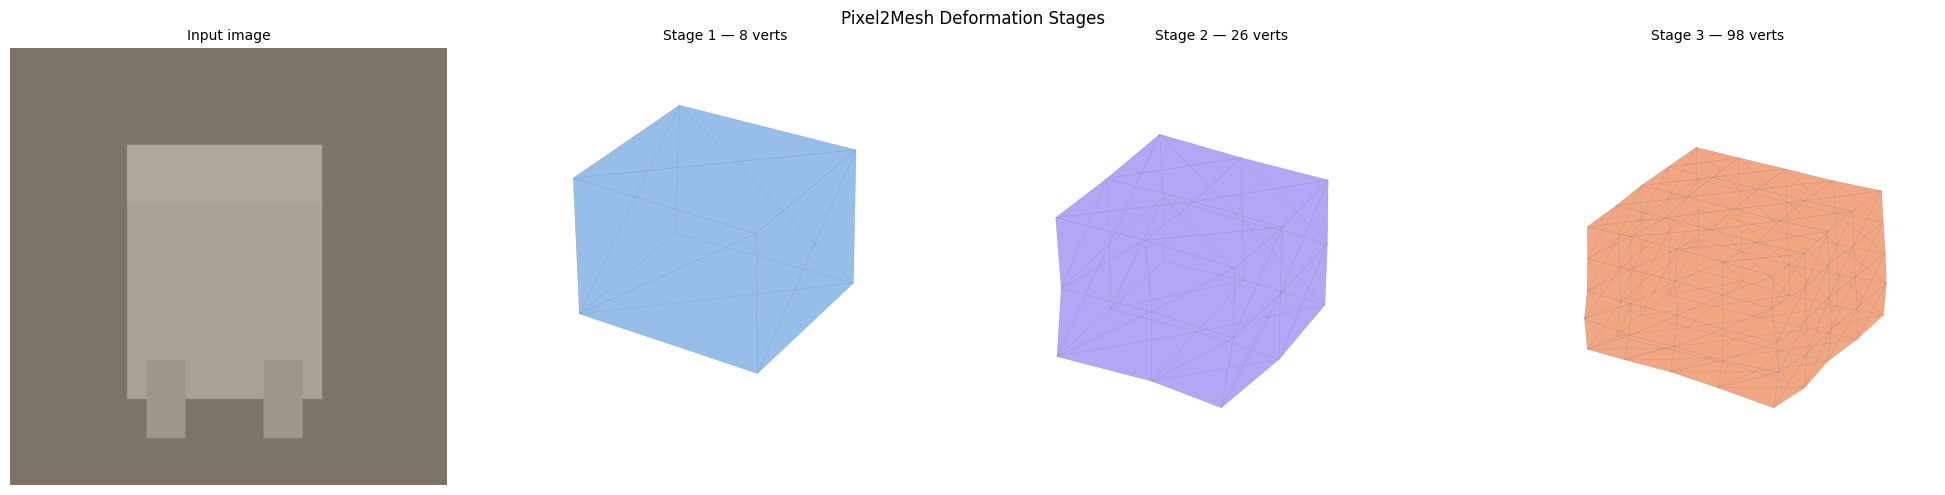

In [7]:
def visualise_output(output, img_tensor=None):
    n_stages = len(output["vertices"])
    n_cols = n_stages + (1 if img_tensor is not None else 0)
    fig = plt.figure(figsize=(5 * n_cols, 5))
    colors = ["#4A90D9", "#7B68EE", "#E8672A"]

    col = 1
    if img_tensor is not None:
        ax = fig.add_subplot(1, n_cols, col)
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        display_img = (img_tensor[0].cpu() * std + mean).clamp(0,1).permute(1,2,0)
        ax.imshow(display_img)
        ax.set_title("Input image", fontsize=10)
        ax.axis("off")
        col += 1

    for i, (verts, faces) in enumerate(zip(output["vertices"], output["faces"])):
        ax = fig.add_subplot(1, n_cols, col, projection="3d")
        pv = verts[0].detach().cpu().numpy()
        ff = faces.cpu().numpy()
        tris = [pv[f] for f in ff]
        poly = Poly3DCollection(tris, alpha=0.35, facecolor=colors[i],
                                edgecolor="#333", linewidth=0.1)
        ax.add_collection3d(poly)
        lim = 0.7
        ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim); ax.set_zlim(-lim,lim)
        ax.set_title(f"Stage {i+1} — {pv.shape[0]} verts", fontsize=10)
        ax.set_axis_off()
        col += 1

    plt.suptitle("Pixel2Mesh Deformation Stages", fontsize=12)
    plt.tight_layout()
    plt.show()


visualise_output(output, img_tensor)

## Export final mesh to OBJ

Stage 3 is the finest mesh (98 verts / 192 faces from the smoke model).

In [8]:
def save_obj(path, vertices, faces):
    """Save a single-batch mesh to an OBJ file."""
    verts = vertices[0].detach().cpu().numpy()  # [V,3]
    faces_np = faces.cpu().numpy()              # [F,3]
    with open(path, "w") as f:
        for v in verts:
            f.write(f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for face in faces_np:
            # OBJ is 1-indexed
            f.write(f"f {face[0]+1} {face[1]+1} {face[2]+1}\n")
    print(f"Saved → {path}  ({len(verts)} verts, {len(faces_np)} faces)")


final_verts = output["vertices"][-1]   # stage 3
final_faces = output["faces"][-1]

save_obj("generated_object.obj", final_verts, final_faces)

Saved → generated_object.obj  (98 verts, 192 faces)


In [9]:
from aspose.threed import Scene, FileFormat
from aspose.threed.formats import *

# Load input OBJ file with Scene class.
scene = Scene.from_file("generated_object.obj");

# Initialize USDSaveOptions class object.
# Specify file format for USDZ
usdSaveOptions = UsdSaveOptions(FileFormat.USDZ);

# Convert OBJ to USDZ file.
scene.save("new.usdz", usdSaveOptions);